# Optimal quoting — stochastic volatility & Gamma/Vega risk (Theorems 4-5)

Phase 2, final section: Stoikov & Sağlam (2009), Section IV. Closes out all three of the paper's quoting regimes (Theorem 1: complete market; Theorems 2-3: illiquid underlying; Theorems 4-5, here: stochastic vol).

**What changes vs. Section III:** the dealer delta-hedges continuously again (like Theorem 1 — no stock quoting), so net Delta is fully hedged away. What's left is residual **Gamma risk** (discrete-hedging error) and **Vega risk** (the option's own implied vol moving, modeled à la Schönbucher 1999: `d(sigma_hat) = alpha*dW`). Only the option is quoted, and its premiums tilt with net **Gamma** exposure (`q_o` alone) instead of net Delta.

This notebook:
1. Reuses the Phase 1 surface and option-intensity calibration
2. Calibrates **alpha** (volatility of implied vol) from real option-trade IV prints — including a real methodology fix found along the way (naively differencing IV across different strikes inflated alpha by ~100x, because adjacent trades on different strikes mostly differ due to static skew, not genuine vol-of-vol)
3. Calibrates gamma from a stated Gamma-risk limit (`implied_gamma_from_option_risk_limit`), the Section IV analogue of the Section III notebooks' risk-limit calibration
4. Runs Theorem 5's multi-period recursion at live-calibrated scale — finds it's negligible there too, for the same structural reason as Section III
5. Reproduces the paper's own Figures 4 & 5 directly: Vega risk dominates for long-dated options, Gamma risk dominates for short-dated ones, with alpha mattering only in the former case
6. Validates `quote_theorem5` collapses exactly to `quote_theorem4` at `n_sessions=1`

New code lives in `src/market_making/quoting.py` (`quote_theorem4`, `quote_theorem5`, `compute_tilt_slope_path_theorem5`, `implied_gamma_from_option_risk_limit`) and `src/market_making/calibration.py` (`implied_vol_of_vol`, `iv` field support in `fetch_trades`).

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('../src'))
sys.path.insert(0, os.path.abspath('../src/vol_surface'))

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import bs
import surface
import data
from market_making import quoting, calibration

%matplotlib inline
np.set_printoptions(precision=6, suppress=True)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

## 1. Build the surface and pick an option

In [2]:
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    surf = surface.run_pipeline('BTC')

r, q = 0.0, 0.0
T0 = float(surf.maturities[len(surf.maturities) // 2])
F0 = float(np.interp(T0, surf.maturities, surf.forwards))
K0 = round(F0 / 500) * 500
S0 = F0
sigma0 = surf.implied_vol(K0, T0)
mid0 = float(bs.price(S0, K0, T0, r, q, sigma0, 'C'))
bs_gamma0 = float(bs.gamma(S0, K0, T0, r, q, sigma0))

print(f"S={S0:.0f}  K={K0:.0f}  T={T0:.4f}  implied_vol={sigma0:.4f}")
print(f"mid={mid0:,.2f}  Gamma={bs_gamma0:.8f}")

S=65695  K=65500  T=0.6219  implied_vol=0.4132
mid=8,586.73  Gamma=0.00001836


## 2. Calibrate option intensity and alpha (vol-of-implied-vol)

Both come from the same trade tape: pool every liquid instrument at K0's own expiry (not the whole chain across expiries, since implied vol level and skew are expiry-specific).

`calibration.implied_vol_of_vol` differences each instrument's own IV series *before* pooling across strikes — the module docstring documents why that matters: pooling raw IV levels across different strikes and differencing across the mixed stream inflated the estimate by roughly 100x on this exact data during development, because two consecutive trades on different strikes mostly differ due to static skew (one strike structurally priced at a higher/lower vol than another), not because the vol level moved between them.

In [3]:
raw_book = data.fetch_book_summary('BTC')
records = raw_book.to_dict('records')

target_expiry = None
for rec in records:
    try:
        expiry, _, _ = data.parse_instrument_name(rec['instrument_name'])
    except Exception:
        continue
    if abs(data.years_to_expiry(expiry) - T0) < 0.01:
        target_expiry = expiry
        break

same_expiry_instruments = []
for rec in records:
    try:
        expiry, _, _ = data.parse_instrument_name(rec['instrument_name'])
    except Exception:
        continue
    if expiry == target_expiry and (rec.get('volume') or 0) > 0:
        same_expiry_instruments.append(rec['instrument_name'])

print(f"{len(same_expiry_instruments)} liquid instruments at K0's expiry ({target_expiry.date()})")

trades = calibration.fetch_trades_multi(same_expiry_instruments, count_each=1000)
print(f"pooled {len(trades)} trades")

option_fit = calibration.calibrate_intensity(trades, min_trades_per_side=20, n_bins=15)
option_bid_intensity = option_fit.bid.intensity.to_absolute(mid0)
print(f"option max premium (bid) = {option_bid_intensity.max_premium:.2f}")

alpha = calibration.implied_vol_of_vol(trades, freq='1min')
print(f"\nalpha (vol-of-implied-vol) = {alpha:.4f}")

30 liquid instruments at K0's expiry (2027-03-26)


pooled 97 trades
option max premium (bid) = 467.89

alpha (vol-of-implied-vol) = 0.1862


## 3. Calibrate physical vol and gamma

`sigma_risk` reuses the same BTC-PERPETUAL realized-vol calibration as the Section III notebooks. `gamma` is calibrated the same way as there too — a stated risk limit, not a market-fit number, since gamma is a preference parameter (see the Theorem 2/3 notebooks for why inverting against real spreads doesn't work). Here the limit is stated directly in net Gamma-exposed option lots, since there's no stock leg to state it in BTC terms against.

In [4]:
perp_trades = calibration.fetch_trades('BTC-PERPETUAL', count=1000)
sigma_risk = calibration.realized_vol(perp_trades, freq='1min')
print(f"sigma_risk = {sigma_risk:.4f}")

horizon = 1 / 365  # 1-day risk-review window, same meaning as Theorem 2/3's horizon
q_o_limit = 20.0   # policy choice: fully aggressive on one side once net Gamma-exposed inventory reaches 20 lots
gamma = quoting.implied_gamma_from_option_risk_limit(
    option_bid_intensity, q_o_limit, bs_gamma0, S0, sigma_risk, alpha, horizon, T0
)
print(f"gamma = {gamma:.3e}  (from a {q_o_limit:.0f}-lot net-Gamma risk limit)")

k = quoting._gamma_vega_risk_k(bs_gamma0, S0, sigma_risk, alpha, horizon, T0)
print(f"k = {k:.4f}   m (= -gamma*k) = {-gamma * k:.6f}")

sigma_risk = 0.1178
gamma = 3.740e-03  (from a 20-lot net-Gamma risk limit)
k = 3208.0625   m (= -gamma*k) = -11.997282


## 4. A quote, and the full inventory sweep

At the stated risk limit, the sweep should span the *entire* premium range (0 to `max_premium`) exactly at `q_o = +/- q_o_limit`, by construction.

q_o=5:  bid/ask = 8,286.80 / 8,766.69  (premiums 299.93 / 179.96)



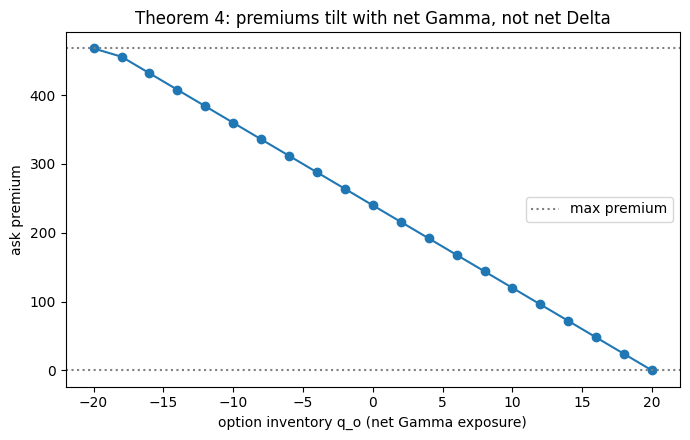

In [5]:
quote = quoting.quote_theorem4(S0, K0, T0, r, q, sigma0, 'C', option_bid_intensity,
                                gamma=gamma, sigma_risk=sigma_risk, alpha=alpha, horizon=horizon, q_o=5.0)
print(f"q_o=5:  bid/ask = {quote.bid_price:,.2f} / {quote.ask_price:,.2f}  "
      f"(premiums {quote.bid_premium:.2f} / {quote.ask_premium:.2f})\n")

q_o_grid = np.linspace(-q_o_limit, q_o_limit, 21)
rows = [
    dict(q_o=q_o, ask=quoting.quote_theorem4(S0, K0, T0, r, q, sigma0, 'C', option_bid_intensity,
                                              gamma=gamma, sigma_risk=sigma_risk, alpha=alpha,
                                              horizon=horizon, q_o=q_o).ask_premium)
    for q_o in q_o_grid
]
sweep_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(sweep_df.q_o, sweep_df.ask, 'o-')
ax.axhline(option_bid_intensity.max_premium, color='gray', linestyle=':', label='max premium')
ax.axhline(0, color='gray', linestyle=':')
ax.set_xlabel('option inventory q_o (net Gamma exposure)')
ax.set_ylabel('ask premium')
ax.set_title('Theorem 4: premiums tilt with net Gamma, not net Delta')
ax.legend()
plt.tight_layout()

## 5. Multi-period recursion at live-calibrated scale

Same question as the Theorem 3 notebook: does the tilt sensitivity actually evolve meaningfully across a trading day at today's real liquidity?

In [6]:
n_sessions = 24
session_dt = horizon / n_sessions

m_live = quoting.compute_tilt_slope_path_theorem5(
    n_sessions, session_dt, horizon, gamma, sigma_risk, S0, bs_gamma0, alpha, T0, option_bid_intensity
)
print(f"m_n (terminal, = Theorem 4's m) = {m_live[-1]:.8f}")
print(f"m_0 (start of day)              = {m_live[0]:.8f}")
print(f"|m_0| / |m_n|                   = {abs(m_live[0]) / abs(m_live[-1]):.6f}")

coef = 2 * option_bid_intensity.D
characteristic_time_years = 1.0 / (coef * abs(m_live[-1]))
print(f"\ncharacteristic timescale for a visible change in m: {characteristic_time_years:.0f} years")
print("-> negligible at today's real calibrated liquidity, same conclusion as Theorem 3 --")
print("   Theorem 4's one-period solution is already an excellent approximation here.")

m_n (terminal, = Theorem 4's m) = -11.99728152
m_0 (start of day)              = -11.99728083
|m_0| / |m_n|                   = 1.000000

characteristic timescale for a visible change in m: 47121 years
-> negligible at today's real calibrated liquidity, same conclusion as Theorem 3 --
   Theorem 4's one-period solution is already an excellent approximation here.


## 6. The paper's own Figures 4 & 5, reproduced

Using the paper's illustrative parameters directly (`A=B=40/2000`, `C=D=40/200`, `S=K=100`, `sigma=0.01`, `gamma=0.1`, `n=100` sessions across `t_n=1`, terminal horizon `T-t_n=0.5`), comparing a **long-dated** option (`T_mat=400`, their Figure 4) against a **very short-dated** one (`T_mat=2`, their Figure 5), each with `alpha=0` vs. `alpha=0.00035`.

The paper's own finding: for the long-dated option, `alpha` has a large effect on the tilt-slope path (Vega risk dominates); for the short-dated option, `alpha` has almost none (Gamma risk dominates, since the Vega term scales with `T_mat^2` while the Gamma term doesn't).

long  maturity, alpha=0.00000:  m_n=-0.000005  m_0=-0.000005  |m_0|/|m_n|=0.9980
long  maturity, alpha=0.00035:  m_n=-0.003865  m_0=-0.001509  |m_0|/|m_n|=0.3905
short maturity, alpha=0.00000:  m_n=-0.000995  m_0=-0.000711  |m_0|/|m_n|=0.7147
short maturity, alpha=0.00035:  m_n=-0.001014  m_0=-0.000721  |m_0|/|m_n|=0.7107


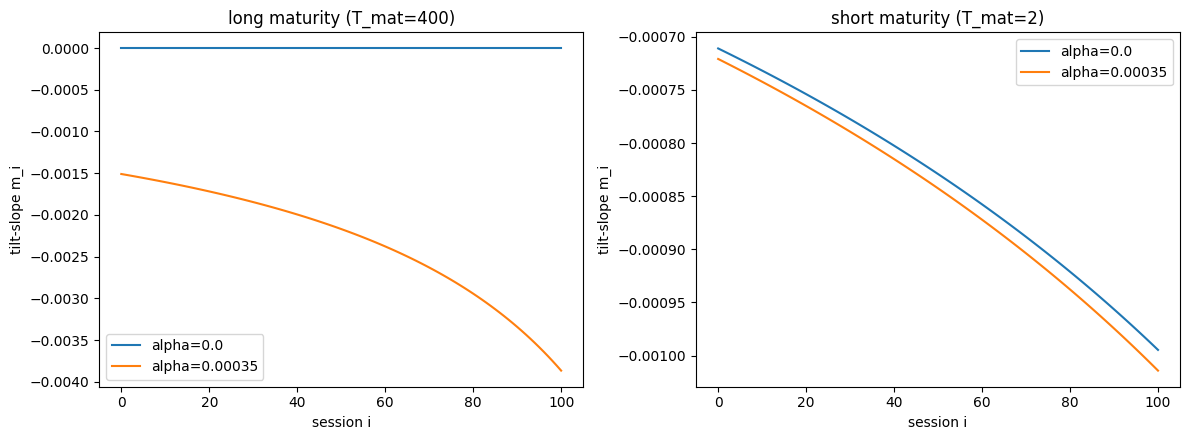

In [7]:
A, B_toy, C, D_toy = 40.0, 2000.0, 40.0, 200.0
S_toy, K_toy, sigma_toy = 100.0, 100.0, 0.01
gamma_toy = 0.1
t0, tn, T_toy = 0.0, 1.0, 1.5
n_sessions_toy = 100
session_dt_toy = (tn - t0) / n_sessions_toy
terminal_horizon_toy = T_toy - tn
option_intensity_toy = quoting.LinearIntensity(C=C, D=D_toy)

results = {}
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)
for ax, (T_mat, label) in zip(axes, [(400.0, 'long maturity (T_mat=400)'), (2.0, 'short maturity (T_mat=2)')]):
    bs_gamma_toy = float(bs.gamma(S_toy, K_toy, T_mat, 0.0, 0.0, sigma_toy))
    for alpha_toy in [0.0, 0.00035]:
        m_toy = quoting.compute_tilt_slope_path_theorem5(
            n_sessions_toy, session_dt_toy, terminal_horizon_toy, gamma_toy, sigma_toy, S_toy,
            bs_gamma_toy, alpha_toy, T_mat, option_intensity_toy,
        )
        results[(T_mat, alpha_toy)] = m_toy
        ax.plot(np.arange(n_sessions_toy + 1), m_toy, label=f'alpha={alpha_toy}')
    ax.set_xlabel('session i'); ax.set_ylabel('tilt-slope m_i')
    ax.set_title(label); ax.legend()
plt.tight_layout()

for (T_mat, alpha_toy), m_toy in results.items():
    label = 'long ' if T_mat == 400.0 else 'short'
    print(f"{label} maturity, alpha={alpha_toy:.5f}:  m_n={m_toy[-1]:.6f}  m_0={m_toy[0]:.6f}  "
          f"|m_0|/|m_n|={abs(m_toy[0]) / abs(m_toy[-1]):.4f}")

## 7. Validate: Theorem 5 collapses to Theorem 4 at `n_sessions=1`

Using the live-calibrated numbers from Sections 1-3.

In [8]:
m_single = quoting.compute_tilt_slope_path_theorem5(
    1, horizon, horizon, gamma, sigma_risk, S0, bs_gamma0, alpha, T0, option_bid_intensity
)

q4 = quoting.quote_theorem4(S0, K0, T0, r, q, sigma0, 'C', option_bid_intensity,
                             gamma=gamma, sigma_risk=sigma_risk, alpha=alpha, horizon=horizon, q_o=6.0)
q5 = quoting.quote_theorem5(S0, K0, T0, r, q, sigma0, 'C', option_bid_intensity, m_next=m_single[-1], q_o=6.0)

print(f"Theorem 4 bid/ask: {q4.bid_premium:.6f} / {q4.ask_premium:.6f}")
print(f"Theorem 5 bid/ask: {q5.bid_premium:.6f} / {q5.ask_premium:.6f}")
print(f"match: {np.isclose(q4.ask_premium, q5.ask_premium) and np.isclose(q4.bid_premium, q5.bid_premium)}")

Theorem 4 bid/ask: 311.929320 / 167.961941
Theorem 5 bid/ask: 311.929320 / 167.961941
match: True


## Wrap-up: all three sections implemented

This closes out the paper end to end -- Theorem 1 (complete market), Theorems 2-3 (illiquid underlying), Theorems 4-5 (stochastic vol), all calibrated against live Deribit data rather than left as toy parameters, with every simplifying assumption documented rather than hidden.

What's still open, specific to this notebook:
- **State-dependent J_i:** same simplification as `compute_tilt_slope_path` (Section III) -- `J_i=2` assumed at every session rather than genuinely tracking whether that session's own premiums are saturated, which would need a full inventory-grid backward induction.
- **Alpha's pooling approximation:** differencing is done within-instrument (fixed, see Section 2), but the *level* being differenced still mixes several strikes at one expiry -- a single option's own long history would be cleaner if enough trades existed for one contract alone.
- **A real inventory tracker, execution, and P&L backtest:** still nothing here persists a live position or validates the policy against realized outcomes -- same caveat as every notebook in this series.
- **The two Sections don't compose:** Section III (illiquid stock, Delta risk) and Section IV (Gamma/Vega risk, hedged Delta) are mutually exclusive regimes in the paper -- a dealer facing *both* illiquid-underlying AND stochastic-vol risk simultaneously isn't covered by either Theorem 2/3 or 4/5 alone.